In [49]:
import stim

from spidercat.utils import qasm_to_stim
from spiderstate.cat_at_origin import *
from spiderstate.utils import load_qecc, count_operations, get_project_root
from spiderstate.fault_tolerance_verification import verify_ftsp
from spiderstate.stim_utils import get_circuit_depth

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
code = "23_1_7"
max_col_ops = 100

print(f"Loading QECC: {code}")
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)

final_circ = cat_at_origin_with_verification(
    H_x=H_x, H_z=H_z, L_x=L_x, L_z=L_z, d=d,
    max_col_ops=max_col_ops, verbose=True, first_layer="X", top_n=10
)

print("\n--- Final Fault Tolerant Verification Circuit ---")
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print(f"Depth: {get_circuit_depth(final_circ)}")
print("Circuit output omitted to avoid terminal spam. You can export or print `final_circ`.")

Loading QECC: 23_1_7
Configuring stabilizers for logical |0> state preparation...
Optimizing parity matrix (max_col_ops=100)...
Computing initial single faults...

Running verification stabilizers search for t=3 layers (top_n=10, first_layer=X)...

--- X Faults Verification (Non-FT) ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 206.0
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 195.0
  [Layer 3] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 207.0
  [Chosen Stabilizers]
    -> Layer 1: ['00000001011110000010010', '00000110110011000000010', '00000110110011000000010', '00001110000100000110010', '00100011010000000101010', '01011010000001001001100']
    -> Layer 2: ['00000011110110100001000', '00001001100101011001000', '00011100100001000011000', '01000001100100000111000', '01000110001001000101000', '10000000000011000111010']
    -> Layer 3: ['00000110011100000001011', '0011100100001000

Num CX: 370


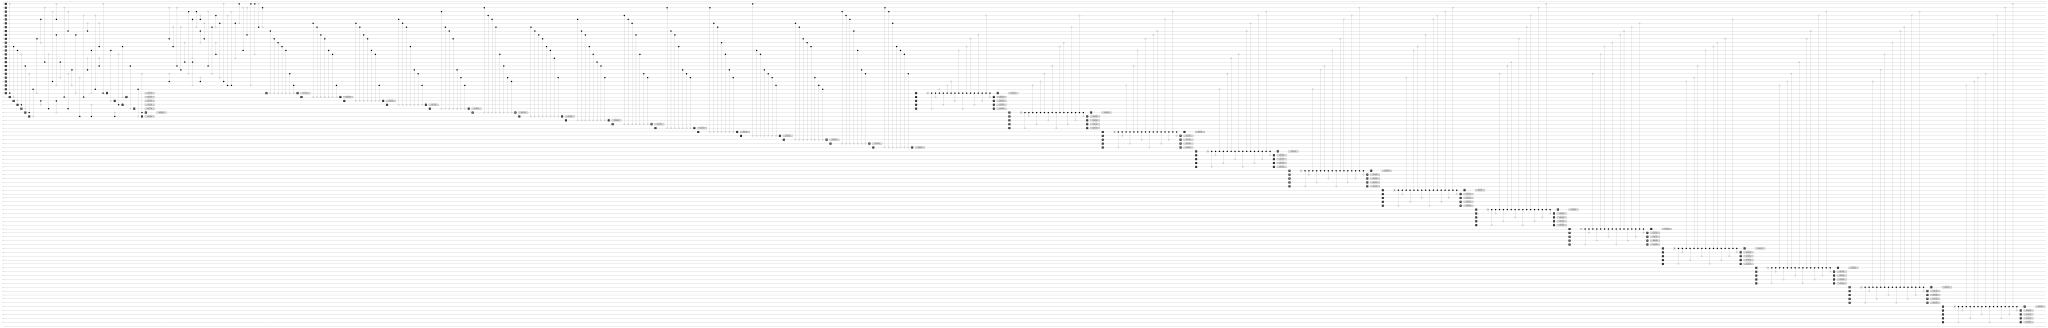

In [51]:
print(f"Num CX: {count_operations(final_circ)[0]}")

final_circ.diagram('timeline-svg')

In [52]:
circuit = final_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(5)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print((meas_samples @ L_z.T % 2).T)

[[0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0]]


In [53]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
        prep_circ=final_circ,
        H_primary=H_z, L_primary=np.atleast_2d(L_z),
        H_conjugate=H_x, L_conjugate=np.atleast_2d(L_x),
        d=d, t=d // 2,
        primary_basis="Z", conjugate_basis="X",
        verbose=True
    )
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis (d=7, t=3)...
    [FAIL] Catastrophic cascade found!
    W(E_init)=3 faults bypassed flags to require only W(E_data)=3 to fail.
    Extracting unified failure circuit (Prep Faults + Data Faults)...
Verification Result: False


In [54]:
res_exhaustive

stim.Circuit('''
    R 0 1 2
    RX 4 8
    R 10
    RX 11 12
    R 13
    RX 15 16
    R 18
    RX 20
    R 21
    RX 22 23
    R 24 25
    RX 26
    R 27
    RX 28
    R 29
    CX 23 0 11 24 12 25 26 13 16 27 28 18 22 29 4 10 15 1 20 2 8 21
    RX 7 9 17
    R 19
    CX 9 23 25 26 27 13 4 0 15 19
    X 15
    CX 24 1 7 2 17 21
    R 3 5 14
    CX 25 28 27 18 8 23 29 19 24 3 7 5 17 14 12 23 29 26 22 3 11 5 16 14 23 0 12 25 29 28 26 13 11 24 16 27
    MX 23
    M 25
    MX 26
    M 24 27
    CX 22 29 28 18
    M 29
    MX 28
    DETECTOR rec[-7]
    DETECTOR rec[-6]
    DETECTOR rec[-5]
    DETECTOR rec[-4]
    DETECTOR rec[-3]
    DETECTOR rec[-2]
    DETECTOR rec[-1]
    TICK
    R 6
    CX 9 1 20 18 11 6 15 10 4 14 16 1 17 6 2 18 15 21 4 3 7 10 20 19 9 5 2 6 13 10
    X 13
    CX 5 19 20 0 12 1 16 2 6 18 5 14 8 1 3 6 0 5 21 3 21 2 0 21 0 13 6 0 1 6
    TICK
    R 23
    CX 7 23 9 23 10 23 11 23 12 23 18 23 21 23
    M 23
    DETECTOR rec[-1]
    R 24
    CX 5 24 6 24 8 24 9 24 12 24

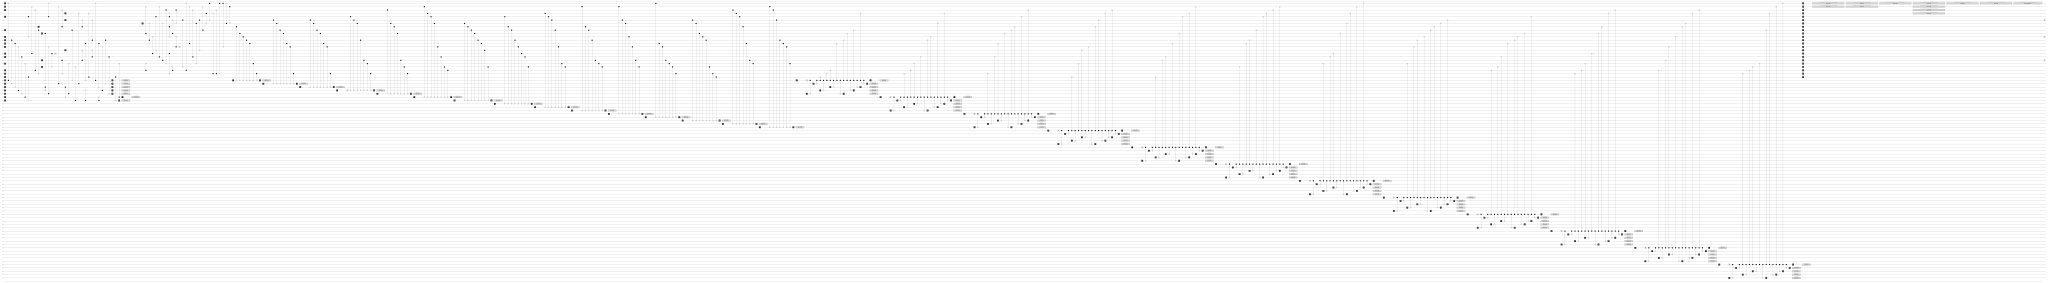

In [55]:
res_exhaustive.diagram("timeline-svg")

In [33]:
if True:
    file = get_project_root().joinpath("good_circuits", f"{code}.stim")
    with open(file, "w") as f:
        f.write(str(final_circ))

Num CX: 76
Total instructions: 89
Depth: 18


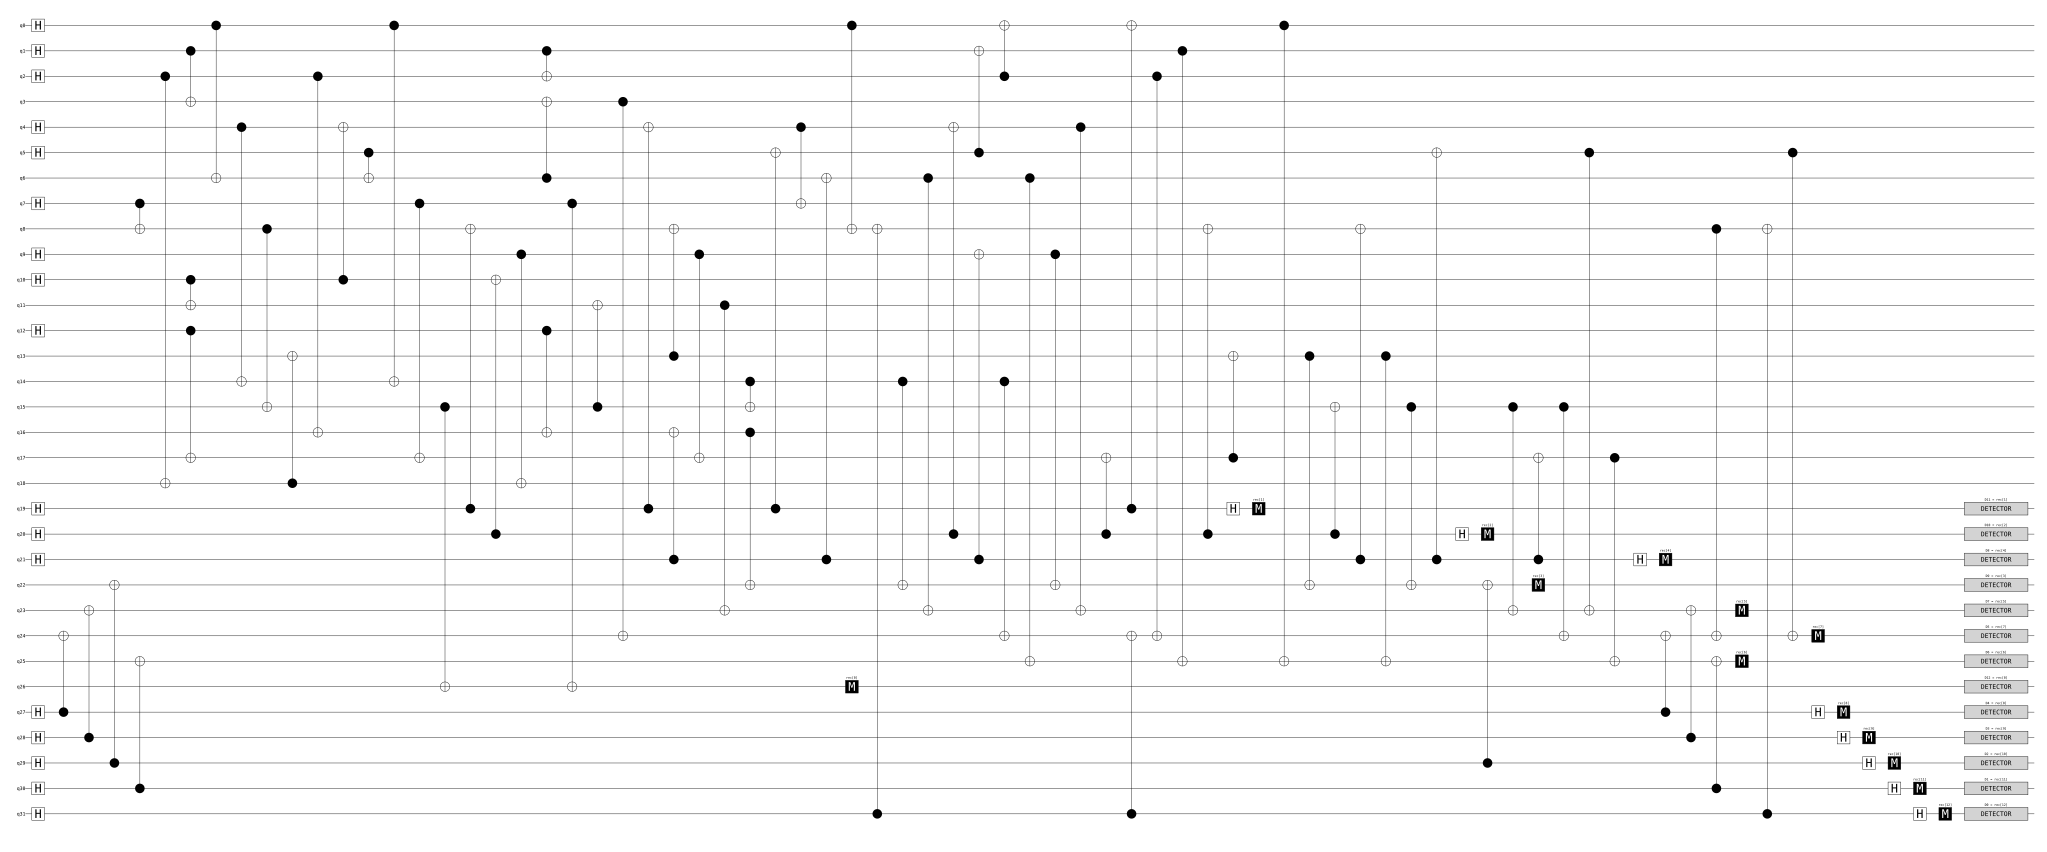

In [29]:
bens_circ = qasm_to_stim("""
OPENQASM 2.0;
include "qelib1.inc";
qreg q[32];
creg c[13];
h q[27];
h q[28];
h q[29];
h q[30];
h q[31];
h q[19];
h q[20];
h q[21];
h q[0];
h q[1];
h q[2];
h q[4];
h q[5];
h q[7];
h q[9];
h q[10];
h q[12];
cx q[27], q[24];
cx q[28], q[23];
cx q[29], q[22];
cx q[30], q[25];
cx q[7], q[8];
cx q[2], q[18];
cx q[12], q[17];
cx q[10], q[11];
cx q[1], q[3];
cx q[0], q[6];
cx q[4], q[14];
cx q[8], q[15];
cx q[18], q[13];
cx q[2], q[16];
cx q[10], q[4];
cx q[5], q[6];
cx q[0], q[14];
cx q[7], q[17];
cx q[15], q[26];
cx q[19], q[8];
cx q[20], q[10];
cx q[9], q[18];
cx q[12], q[16];
cx q[6], q[3];
cx q[1], q[2];
cx q[7], q[26];
cx q[15], q[11];
cx q[3], q[24];
cx q[19], q[4];
cx q[13], q[8];
cx q[21], q[16];
cx q[9], q[17];
cx q[11], q[23];
cx q[14], q[15];
cx q[16], q[22];
cx q[19], q[5];
cx q[4], q[7];
cx q[21], q[6];
cx q[0], q[8];
measure q[26] -> c[0];
cx q[31], q[8];
cx q[14], q[22];
cx q[6], q[23];
cx q[20], q[4];
cx q[5], q[1];
cx q[21], q[9];
cx q[2], q[0];
cx q[14], q[24];
cx q[6], q[25];
cx q[9], q[22];
cx q[4], q[23];
cx q[20], q[17];
cx q[19], q[0];
cx q[31], q[24];
cx q[2], q[24];
cx q[1], q[25];
cx q[20], q[8];
cx q[17], q[13];
h q[19];
measure q[19] -> c[1];
cx q[0], q[25];
cx q[13], q[22];
cx q[20], q[15];
cx q[21], q[8];
cx q[13], q[25];
cx q[15], q[22];
cx q[21], q[5];
h q[20];
measure q[20] -> c[2];
cx q[29], q[22];
cx q[15], q[23];
cx q[21], q[17];
measure q[22] -> c[3];
cx q[15], q[24];
cx q[5], q[23];
cx q[17], q[25];
h q[21];
measure q[21] -> c[4];
cx q[27], q[24];
cx q[28], q[23];
cx q[30], q[25];
cx q[8], q[24];
measure q[23] -> c[5];
measure q[25] -> c[6];
cx q[31], q[8];
cx q[5], q[24];
measure q[24] -> c[7];
h q[27];
measure q[27] -> c[8];
h q[28];
measure q[28] -> c[9];
h q[29];
measure q[29] -> c[10];
h q[30];
measure q[30] -> c[11];
h q[31];
measure q[31] -> c[12];
""")
for i in range(bens_circ.num_measurements):
    bens_circ.append("DETECTOR", [stim.target_rec(-i-1)])


print(f"Num CX: {count_operations(bens_circ)[0]}")
print(f"Total instructions: {sum(count_operations(bens_circ))}")
print(f"Depth: {get_circuit_depth(bens_circ)}")
bens_circ.diagram("timeline-svg")

In [30]:
z_stabs_19_1_5 = x_stabs_19_1_5 = np.array([
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1],
])
z_logs_19_1_5 = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

z_stabs_17_1_5 = x_stabs_17_1_5 = np.array([
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1],
])
z_logs_17_1_5 = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

circuit = bens_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ z_stabs_19_1_5.T % 2)
print(meas_samples @ z_logs_19_1_5.T % 2)

[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]
[0 0 0 0 0 0 0 0 0 0]


In [31]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
    prep_circ=bens_circ,
    H_primary=z_stabs_19_1_5, L_primary=np.atleast_2d(z_logs_19_1_5),
    H_conjugate=z_stabs_19_1_5, L_conjugate=np.atleast_2d(z_logs_19_1_5),
    d=5, t=2,
    primary_basis="Z", conjugate_basis="X",
    verbose=True
)
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis (d=5, t=2)...
    [PASS] UNSAT. The state preparation is strictly Fault-Tolerant.

  [Conjugate] Evaluating X-basis via Combinatorics (t=2)...
    [PASS] No uncorrectable conjugate cascades found.
Verification Result: True


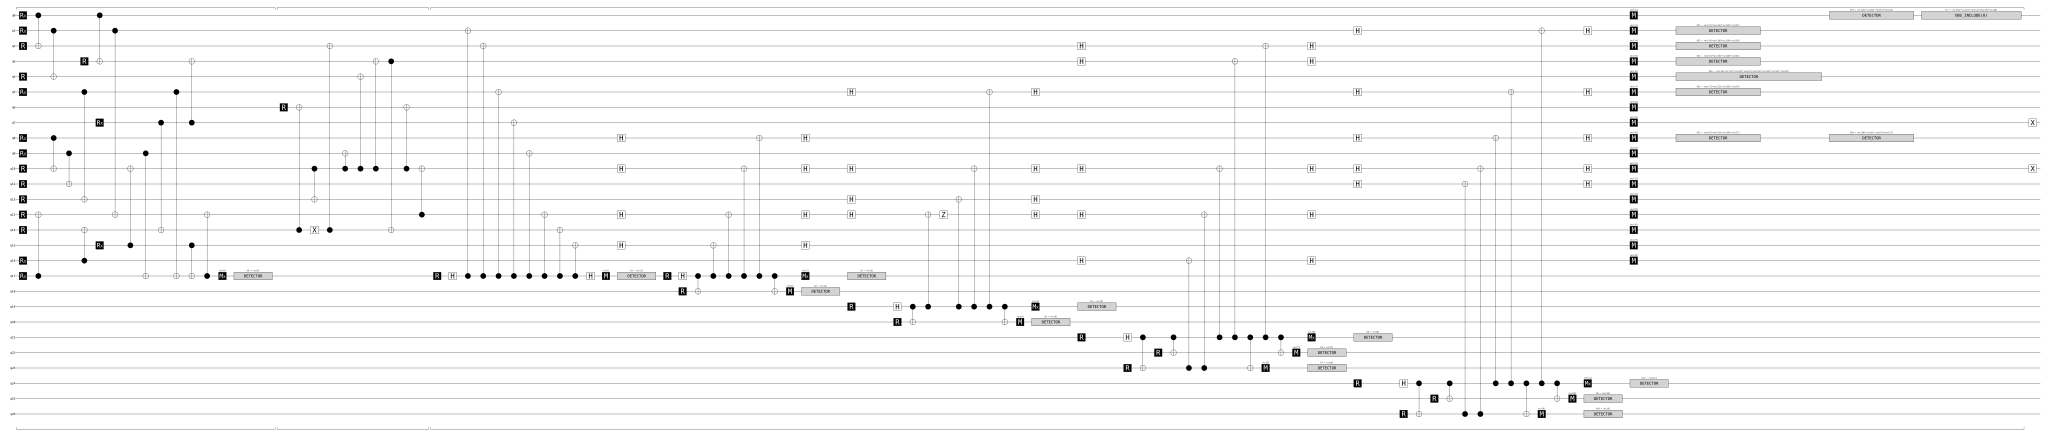

In [129]:
res_exhaustive.diagram('timeline-svg')